In [1]:
import itertools
import pandas as pd
import numpy as np
from mixbox import lerp
from collections import OrderedDict

def generate_permutative_data(params):
    """
    Generates all possible permutations of given parameters with their specified ranges and number of data points.
    
    Args:
        params (OrderedDict): Ordered dictionary where keys are parameter names,
                              and values are tuples of (start, end, num_points).
    
    Returns:
        pd.DataFrame: DataFrame containing all permutative combinations.
    """
    param_names = list(params.keys())

    # Generate parameter values dynamically based on number of points
    param_values = [
        np.linspace(start, end, num_points).tolist()  # Ensures exact number of points
        for start, end, num_points in params.values()
    ]

    # Generate all permutations
    data = list(itertools.product(*param_values))

    # Convert to DataFrame
    df = pd.DataFrame(data, columns=param_names)
    return df


In [2]:
def lerp_columns(row):
    return lerp((
        int(row['r1']),
        int(row['g1']),
        int(row['b1']),), (
        int(row['r2']),
        int(row['g2']),
        int(row['b2']),), 
        row['t'])

In [3]:

params = OrderedDict([
    ("r1", (0, 255, 5)),
    ("g1", (0, 255, 5)),
    ("b1", (0, 255, 5)),
    ("r2", (0, 255, 5)),
    ("g2", (0, 255, 5)),
    ("b2", (0, 255, 5)),
    ("t", (0.0, 1.0, 11))
])

df = generate_permutative_data(params)
df


,r1,g1,b1,r2,g2,b2,t
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.2
3,0.0,0.0,0.0,0.0,0.0,0.0,0.3
4,0.0,0.0,0.0,0.0,0.0,0.0,0.4
...,...,...,...,...,...,...,...
171870,255.0,255.0,255.0,255.0,255.0,255.0,0.6
171871,255.0,255.0,255.0,255.0,255.0,255.0,0.7
171872,255.0,255.0,255.0,255.0,255.0,255.0,0.8
171873,255.0,255.0,255.0,255.0,255.0,255.0,0.9


In [4]:
# Apply the function to each row and create a new column
df[['rr', 'gr', 'br']] = df.apply(lerp_columns, axis=1).apply(pd.Series)
df

,r1,g1,b1,r2,g2,b2,t,rr,gr,br
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0,0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0,0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0,0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0,0,0
...,...,...,...,...,...,...,...,...,...,...
171870,255.0,255.0,255.0,255.0,255.0,255.0,0.6,255,255,255
171871,255.0,255.0,255.0,255.0,255.0,255.0,0.7,255,255,255
171872,255.0,255.0,255.0,255.0,255.0,255.0,0.8,255,255,255
171873,255.0,255.0,255.0,255.0,255.0,255.0,0.9,255,255,255


In [5]:
df.to_csv("lerpdata.csv", index=False)

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [7]:
# Split dataset into features (X) and target values (y)
X = df[['r1','g1','b1','r2','g2','b2','t']]       # Input features
y = df[['rr','gr','br']] # Output labels

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Display predictions alongside actual values
results_df = pd.DataFrame({
    "Actual result1": y_test.iloc[:, 0],
    "Predicted result1": y_pred[:, 0],
    "Actual result2": y_test.iloc[:, 1],
    "Predicted result2": y_pred[:, 1]
})

Mean Absolute Error: 3.2298
R² Score: 0.9961


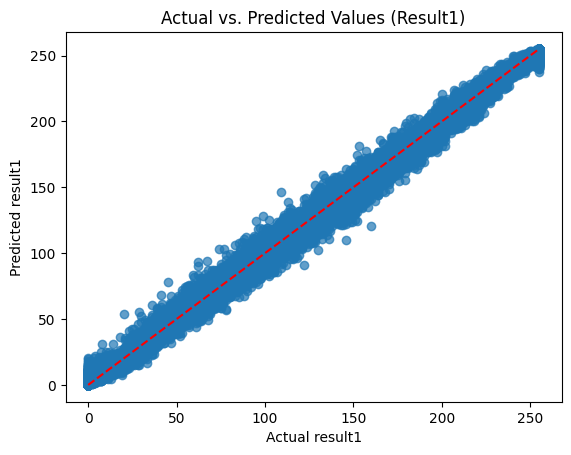

In [10]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted for result1
plt.scatter(y_test.iloc[:, 0], y_pred[:, 0], alpha=0.7)
plt.xlabel("Actual result1")
plt.ylabel("Predicted result1")
plt.title("Actual vs. Predicted Values (Result1)")
plt.plot([min(y_test.iloc[:, 0]), max(y_test.iloc[:, 0])], 
         [min(y_test.iloc[:, 0]), max(y_test.iloc[:, 0])], 
         color='red', linestyle='--')  # Diagonal line
plt.show()


In [23]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Define the polynomial regression model (degree=4 for non-linearity)
degree = 4  # Adjust this to control polynomial complexity
poly = PolynomialFeatures(degree)  # Polynomial transformation
scaler = StandardScaler()  # Feature scaling
lin_reg = LinearRegression()  # Linear regression model

# Transform features and fit the model
X_train_poly = poly.fit_transform(X_train)  # Generate polynomial features
X_test_poly = poly.transform(X_test)

scaler.fit(X_train_poly)  # Fit scaler on training data
X_train_scaled = scaler.transform(X_train_poly)  # Scale training features
X_test_scaled = scaler.transform(X_test_poly)  # Scale test features

lin_reg.fit(X_train_scaled, y_train)  # Train model

# Make predictions
y_pred = lin_reg.predict(X_test_scaled)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Extract the polynomial equation
feature_names = poly.get_feature_names_out(X_train.columns)  # Get polynomial terms
coefficients = lin_reg.coef_  # Get coefficients
intercept = lin_reg.intercept_  # Get intercept

# Print the equation for each output variable
for i, target in enumerate(y_train.columns):
    equation_terms = [f"{coeff:.4f}*{feature}" for coeff, feature in zip(coefficients[i], feature_names)]
    equation = " + ".join(equation_terms)
    print(f"\nPolynomial Regression Equation for {target}:")
    print(f"{target} = {intercept[i]:.4f} + {equation}")


Mean Absolute Error: 2.5439
R² Score: 0.9976

Polynomial Regression Equation for rr:
rr = 126.4915 + 0.0000*1 + 85.4018*r1 + -4.1276*g1 + -7.1620*b1 + -3.0313*r2 + -3.5128*g2 + -7.4963*b2 + -5.8164*t + 2.7816*r1^2 + -14.9672*r1 g1 + 10.9846*r1 b1 + 15.5822*r1 r2 + 12.4720*r1 g2 + -4.4279*r1 b2 + -58.7087*r1 t + 16.3804*g1^2 + 12.8250*g1 b1 + 13.5395*g1 r2 + -9.4740*g1 g2 + 0.5062*g1 b2 + 2.8891*g1 t + 6.9650*b1^2 + -5.9575*b1 r2 + 0.6412*b1 g2 + 8.7868*b1 b2 + 2.8253*b1 t + 0.1758*r2^2 + -14.8478*r2 g2 + 9.1059*r2 b2 + 81.3865*r2 t + 17.2787*g2^2 + 11.3528*g2 b2 + 2.9904*g2 t + 8.2773*b2^2 + -4.6617*b2 t + 5.3741*t^2 + -6.7504*r1^3 + 14.4074*r1^2 g1 + 4.7690*r1^2 b1 + -5.2325*r1^2 r2 + -4.5415*r1^2 g2 + -7.5644*r1^2 b2 + -23.8961*r1^2 t + -0.3551*r1 g1^2 + 11.7945*r1 g1 b1 + -4.8856*r1 g1 r2 + -5.7987*r1 g1 g2 + -1.5686*r1 g1 b2 + -23.9920*r1 g1 t + -24.8176*r1 b1^2 + -3.1826*r1 b1 r2 + -3.4117*r1 b1 g2 + 2.1582*r1 b1 b2 + 9.8881*r1 b1 t + -3.0742*r1 r2^2 + -4.7972*r1 r2 g2 + -0.9683*r

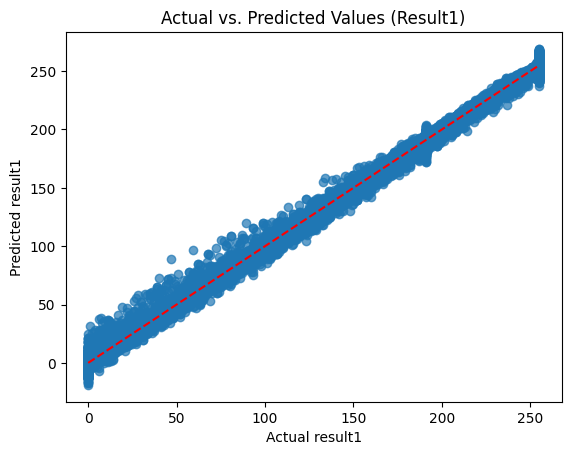

In [24]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted for result1
plt.scatter(y_test.iloc[:, 0], y_pred[:, 0], alpha=0.7)
plt.xlabel("Actual result1")
plt.ylabel("Predicted result1")
plt.title("Actual vs. Predicted Values (Result1)")
plt.plot([min(y_test.iloc[:, 0]), max(y_test.iloc[:, 0])], 
         [min(y_test.iloc[:, 0]), max(y_test.iloc[:, 0])], 
         color='red', linestyle='--')  # Diagonal line
plt.show()
